# Импорт библиотек и настройка среды

In [190]:
import pandas as pd
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

In [191]:
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Бизнес-цель

**Главная бизнес-задача:**

Оценить trade-off между долей сохранённых заёмщиков и долей отсеянных bad events при различных cutoff-сценариях и определить статистически разумный диапазон reject rate для использования модели в качестве risk-фильтра.

**Ограничения:**

1. Датасет не содержит информации о величине кредитной экспозиции, доходности заёмщиков и фактических кредитных потерях. Поэтому выбор cutoff можно обосновать только статистически, но не экономически. Полученный диапазон reject rate нельзя интерпретировать как окончательно оптимальный для бизнеса.
2. Модельный risk score не является откалиброванной вероятностью дефолта и систематически отличается от observed bad rate. Поэтому правило отсечения нельзя обосновывать абсолютным значением score. В рамках анализа сценарии задаются по доле наиболее рискованных заёмщиков: top 5%, 10%, 15% и т. д.

# Вспомогательные функции

## Функция для создания таблицы cutoff-сценариев

In [192]:
def make_scenario_table(
    data: pd.DataFrame,
    quantiles: list[float] = [1.00, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70]
) -> pd.DataFrame:
    scenario_tables = pd.DataFrame(columns=[
        "Scenario",
        "All Borrowers",
        "Approved Borrowers",
        "Approved Bad Rate",
        "Bads",
        "Approved Bads",
        "Rejected Bads",
        "Reject Bad Rate",
        "Bad Capture Rate"
    ])

    dataset_size = data.shape[0] * 1.0
    dataset_num_bads = data["target"].sum() * 1.0

    for reject_rate in quantiles:
        reject = data.query(f"score > {data["score"].quantile(reject_rate)}")
        approved = data.query(f"score <= {data["score"].quantile(reject_rate)}")

        approved_borrowers = approved.shape[0]
        approved_num_bads = approved["target"].sum() * 1.0
        approved_bad_rate = approved_num_bads / approved_borrowers

        reject_borrowers = reject.shape[0]
        reject_num_bads = reject["target"].sum() * 1.0
        reject_bad_rate = (
            reject_num_bads / reject_borrowers
            if reject_borrowers > 0
            else float("nan")
        )

        bad_capture_rate = reject_num_bads / dataset_num_bads

        scenario_tables.loc[ scenario_tables.shape[0] ] = [
            f"reject {1.0 - reject_rate:.2f}",
            int(dataset_size),
            approved_borrowers,
            approved_bad_rate,
            int(dataset_num_bads),
            approved_num_bads,
            reject_num_bads,
            reject_bad_rate,
            bad_capture_rate
        ]

    scenario_tables["Additional Rejected Bad Borrowers"] = (
        scenario_tables["Bad Capture Rate"].diff()
    )

    return scenario_tables

## Функции для визуализации trade-off между ценой и эффектом кредитной политики

In [193]:
def plot_approved_borrowers_and_bads(
    scenario_table: pd.DataFrame
) -> None:
    reject_rate = (
        scenario_table["Scenario"]
        .str.replace("reject ", "", regex=False)
        .astype(float)
        * 100
    )

    approved_borrowers_share = (
        scenario_table["Approved Borrowers"]
        / scenario_table["All Borrowers"]
        * 100
    )

    approved_bads_share = (
        scenario_table["Approved Bads"]
        / scenario_table["Bads"]
        * 100
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        reject_rate,
        approved_borrowers_share,
        marker="o",
        linewidth=2,
        label="Approved Borrowers"
    )

    ax.plot(
        reject_rate,
        approved_bads_share,
        marker="o",
        linewidth=2,
        label="Approved Bads"
    )

    ax.set_xlabel("Reject Rate, %")
    ax.set_ylabel("Remaining Population, %")
    ax.set_title(
        "Approved Borrowers vs Approved Bads"
    )

    ax.set_xticks(reject_rate)
    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

In [194]:
def plot_price_and_effect_of_the_policy(
    scenario_table: pd.DataFrame
) -> None:
    reject_rate = (
        scenario_table["Scenario"]
        .str.replace("reject ", "", regex=False)
        .astype(float)
        * 100
    )

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 2, 1)
    plt.bar(
        reject_rate,
        scenario_table["All Borrowers"],
        width=3.5,
        alpha=0.35,
        label="All Borrowers"
    )
    plt.bar(
        reject_rate,
        scenario_table["Approved Borrowers"],
        width=2.2,
        label="Approved Borrowers"
    )
    plt.xlabel("Reject Rate, %")
    plt.ylabel("Borrowers")
    plt.title(
        "All Borrowers vs Approved Borrowers"
    )
    plt.xticks(reject_rate)
    plt.legend()
    plt.grid(axis="y", alpha=0.25)

    plt.subplot(1, 2, 2)
    plt.bar(
        reject_rate,
        scenario_table["Bads"],
        width=3.5,
        alpha=0.35,
        label="All Bads"
    )
    plt.bar(
        reject_rate,
        scenario_table["Approved Bads"],
        width=2.2,
        label="Approved Bads"
    )
    plt.xlabel("Reject Rate, %")
    plt.ylabel("Bad Borrowers")
    plt.title(
        "All Bads vs Approved Bads"
    )
    plt.xticks(reject_rate)
    plt.legend()
    plt.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

# Загрузка датасета

Загружаем только тестовую часть датасета, которая не использовалась при обучении скоринговой модели. Это позволяет оценивать эффект cutoff-сценариев на независимой holdout-выборке и не получать оптимистичную оценку качества кредитной политики.

In [195]:
data = pd.read_csv("../data/scoring_data/test.csv")

# Загрузка скоринговой модели

In [196]:
model = CatBoostClassifier()
model.load_model("../data/models_data/catboost_model.cbm")

CatBoostClassifier(auto_class_weights='SqrtBalanced', depth=6, iterations=400, l2_leaf_reg=3.764758109, learning_rate=0.0377303516, loss_function='Logloss', random_seed=42, random_strength=1, thread_count=1, verbose=0)

# Оценка заёмщиков

Вычисление risk score заёмщиков. Чем выше значение score, тем выше модельная оценка относительного кредитного риска. Поскольку score не откалиброван как вероятность дефолта, далее он используется для ранжирования заёмщиков, а не как абсолютная PD.

In [197]:
data["score"] = model.predict_proba(data.drop(columns="target"))[:, 1]

Ранжирование заёмщиков по убыванию risk score: от наиболее рискованных к наименее рискованным.

In [198]:
data = data.sort_values(by="score", ascending=False).reset_index(drop=True)

# Проведение cutoff анализа

Вычисление таблицы различных cutoff сценариев.

In [199]:
scenario_tables = make_scenario_table(data=data)

In [200]:
scenario_tables

,Scenario,All Borrowers,Approved Borrowers,Approved Bad Rate,Bads,Approved Bads,Rejected Bads,Reject Bad Rate,Bad Capture Rate,Additional Rejected Bad Borrowers
0,reject 0.00,15000,15000,0.0669,1003,"1,003.0000",0.0000,NaN,0.0000,NaN
1,reject 0.05,15000,14250,0.0445,1003,634.0000,369.0000,0.4920,0.3679,0.3679
2,reject 0.10,15000,13500,0.0325,1003,439.0000,564.0000,0.3760,0.5623,0.1944
3,reject 0.15,15000,12750,0.0259,1003,330.0000,673.0000,0.2991,0.6710,0.1087
4,reject 0.20,15000,12000,0.0220,1003,264.0000,739.0000,0.2463,0.7368,0.0658
5,reject 0.25,15000,11250,0.0180,1003,202.0000,801.0000,0.2136,0.7986,0.0618
6,reject 0.30,15000,10500,0.0150,1003,158.0000,845.0000,0.1878,0.8425,0.0439


Визуализируем trade-off между потерей approval volume и снижением количества bad events при последовательном увеличении reject rate.

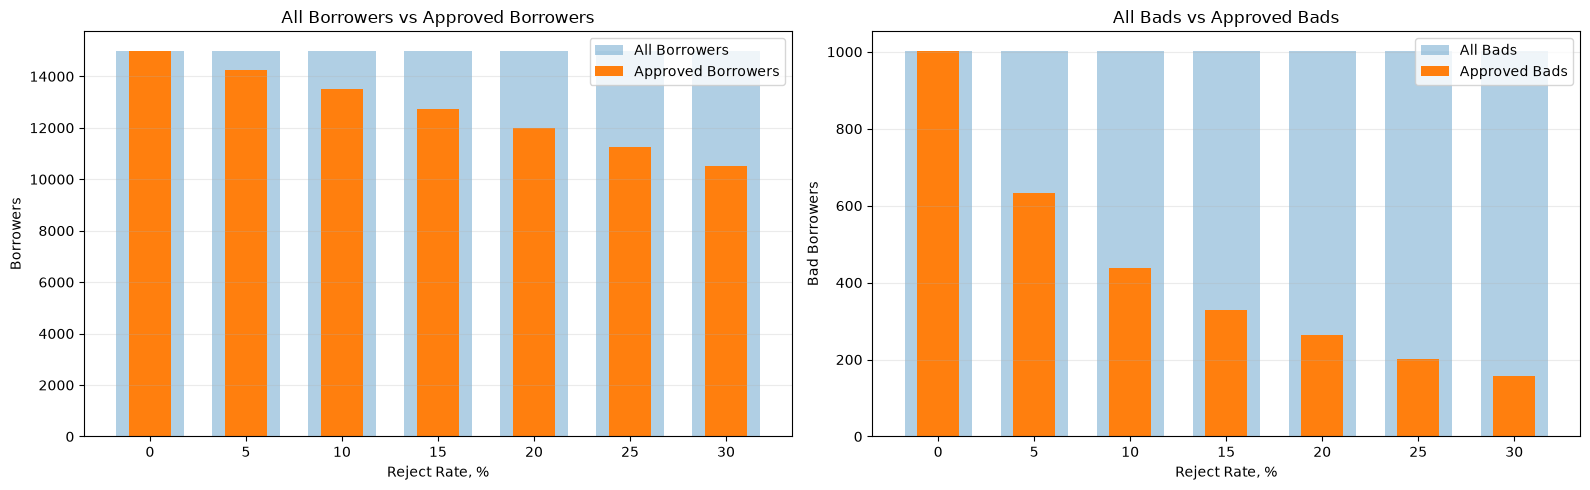

In [201]:
plot_price_and_effect_of_the_policy(
    scenario_table=scenario_tables
)

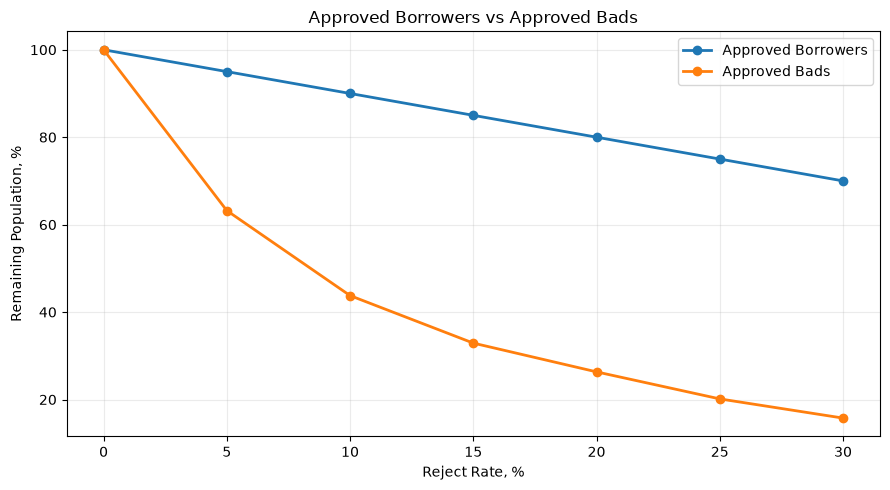

In [202]:
plot_approved_borrowers_and_bads(
    scenario_table=scenario_tables
)

**Вывод по сценариям:**

Cutoff-анализ показывает выраженный diminishing return при увеличении reject rate. Первые 5% наиболее рискованных заёмщиков концентрируют около 36.8% всех bad events. При увеличении reject rate до 10% bad capture возрастает до 56.2%, а при 15% — до 67.1%, при этом сохраняется соответственно 90% и 85% заёмщиков.

После reject rate около 15% дополнительный эффект от дальнейшего ужесточения политики заметно снижается. Переход от 15% к 20% уменьшает approval volume ещё на 5 п.п., но увеличивает bad capture только примерно на 6.6 п.п. На последующих шагах marginal gain становится ещё ниже.

Таким образом, диапазон reject rate 10–15% выглядит разумным статистическим trade-off между сохранением объёма одобрений и отсечением bad events. Однако без информации о доходности, кредитной экспозиции и стоимости кредитных потерь этот диапазон нельзя интерпретировать как экономически оптимальный cutoff.

**Для дальнейшего анализа в качестве статистически разумного диапазона credit-policy cutoff будем рассматривать отсечение top 10–15% наиболее рискованных заёмщиков. Данный диапазон является аналитическим ориентиром, а не экономически оптимальным правилом кредитной политики.**